# Credit Card Fraud Detection

Scores each transaction for fraud probability and picks an action (allow, review, or block). Goal: lowest expected dollar loss, not best AUC number.

Contents:

1. Comparison of five models: Logistic Regression, Random Forest, XGBoost, XGBoost + SMOTE, XGBoost + class_weight.
2. PR curves (primary metric at 0.17% positives) and ROC curves.
3. Cost matrix, a threshold picked to minimize expected cost, and a sensitivity sweep.
4. SHAP on the best model: global summary and local waterfalls for a caught fraud, a missed fraud, and a false alarm.
5. Bundle with model, scaler, thresholds, and cost assumptions.

Dataset: Kaggle mlg-ulb/creditcardfraud. 284,807 transactions over two days in September 2013, 492 labeled fraud (0.172%). V1 to V28 are PCA components. Time and Amount are raw. Put creditcard.csv in the working directory before running.

Runtime: 3 to 5 minutes on a laptop.


## 0. Setup

In [1]:
# Run once per environment. Safe to re-run.
%pip install -q xgboost shap imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

SEED = 42
np.random.seed(SEED)
DATA_PATH = "~/Downloads/creditcard.csv"
ARTIFACT_PATH = "fraud_model_artifact.pkl"


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and sanity check

Quick look. If there are nulls, the column count is wrong, or the fraud rate isn't around 0.172%, the file is bad and we stop.


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape:         {df.shape}")
print(f"Nulls:         {df.isnull().sum().sum()}")
print(f"Class counts:  {df['Class'].value_counts().to_dict()}")
print(f"Fraud rate:    {df['Class'].mean()*100:.4f}%")
df.head()


Shape:         (284807, 31)
Nulls:         0
Class counts:  {0: 284315, 1: 492}
Fraud rate:    0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 2. EDA

Three things matter for later:

1. Class balance. Explains why PR-AUC is the main metric, not accuracy or ROC-AUC.
2. Amount by class. The mean fraud amount goes into the cost matrix in §6.
3. Time. Confirms the two-day window and day/night pattern, motivates the note on temporal splits in §3.


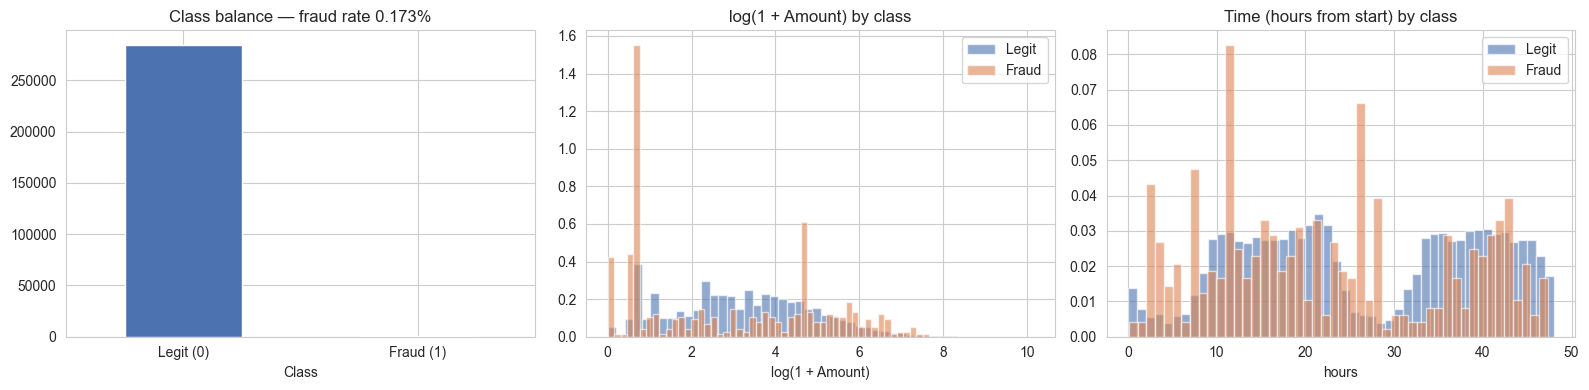


Mean fraud transaction amount:   $122.21
Median fraud transaction amount: $9.25
→ We use the mean as the per-miss cost baseline in the cost matrix (§6).


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'])
axes[0].set_title(f"Class balance — fraud rate {df['Class'].mean()*100:.3f}%")
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)

axes[1].hist(np.log1p(df.loc[df.Class == 0, 'Amount']), bins=50, alpha=0.6, label='Legit', color='#4c72b0', density=True)
axes[1].hist(np.log1p(df.loc[df.Class == 1, 'Amount']), bins=50, alpha=0.6, label='Fraud', color='#dd8452', density=True)
axes[1].set_title("log(1 + Amount) by class")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].legend()

axes[2].hist(df.loc[df.Class == 0, 'Time'] / 3600, bins=48, alpha=0.6, label='Legit', color='#4c72b0', density=True)
axes[2].hist(df.loc[df.Class == 1, 'Time'] / 3600, bins=48, alpha=0.6, label='Fraud', color='#dd8452', density=True)
axes[2].set_title("Time (hours from start) by class")
axes[2].set_xlabel("hours"); axes[2].legend()

plt.tight_layout(); plt.show()

mean_fraud_amount = df.loc[df.Class == 1, 'Amount'].mean()
median_fraud_amount = df.loc[df.Class == 1, 'Amount'].median()
print(f"\nMean fraud transaction amount:   ${mean_fraud_amount:.2f}")
print(f"Median fraud transaction amount: ${median_fraud_amount:.2f}")
print("→ We use the mean as the per-miss cost baseline in the cost matrix (§6).")


## 3. Preprocessing and split

Two things worth noting:

Scaling: V1 to V28 are already PCA components, so leave them alone. Amount is heavy-tailed, RobustScaler handles that better than StandardScaler. Time is scaled for LR. Fit the scaler on train only so nothing leaks into the test set.

Random split vs. time split: the data covers 48 hours, so a time split would leave one side very small. Stratified random is used here. In production add a time-based holdout (last N days) since fraud patterns drift. See README.


In [5]:
X = df.drop(columns=['Class']).copy()
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Fit scaler on train only
scaler = RobustScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print(f"Train: {X_train.shape}, positives={y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test:  {X_test.shape}, positives={y_test.sum()} ({y_test.mean()*100:.3f}%)")


Train: (227845, 30), positives=394 (0.173%)
Test:  (56962, 30), positives=98 (0.172%)


## 4. Why no Isolation Forest

The previous notebook ran Isolation Forest as an outlier pass and dropped the flagged points before training. That step is removed.

Isolation Forest is unsupervised. We have 492 labeled frauds, which is real signal a gradient booster can learn directly. And because fraud is itself anomalous, Isolation Forest flags some labeled positives as outliers and drops them, which hurts recall.

Where Isolation Forest does make sense:

- Cold-start, few labels. New card product, new merchant category.
- Parallel challenger for attack types the supervised model hasn't seen.
- Drift monitor. Rising anomaly rate on low-score transactions is a retrain signal.

Recommendation for ops: run it in shadow for the last two. Keep it out of the training pipeline.


## 5. Model comparison

Five models on the same train/test split: Logistic Regression, Random Forest, XGBoost, XGBoost + SMOTE, XGBoost + class_weight. XGBoost is the main candidate. Random Forest is the baseline from the previous notebook. Logistic Regression sets the floor.

XGBoost vs LightGBM: either works. XGBoost has better SHAP TreeExplainer support and is more common in tabular fraud work. LightGBM would score within noise on this dataset.


In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost (neg/pos ratio) = {scale_pos_weight:.1f}")

xgb_params = dict(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='aucpr', tree_method='hist',
    random_state=SEED, n_jobs=-1,
)

models = {}


models['LogisticRegression'] = LogisticRegression(
    max_iter=1000, solver='liblinear', random_state=SEED
).fit(X_train, y_train)

models['RandomForest'] = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=SEED
).fit(X_train, y_train)

models['XGBoost'] = xgb.XGBClassifier(**xgb_params).fit(X_train, y_train)

models['XGBoost+SMOTE'] = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', xgb.XGBClassifier(**xgb_params)),
]).fit(X_train, y_train)

models['XGBoost+class_weight'] = xgb.XGBClassifier(
    **{**xgb_params, 'scale_pos_weight': scale_pos_weight}
).fit(X_train, y_train)

print("All five models fitted.")

scale_pos_weight for XGBoost (neg/pos ratio) = 577.3
All five models fitted.


### 5.1 Comparison table

Primary metric: PR-AUC (average precision). At 0.17% positives, ROC-AUC looks better than it really is. A model can have a nice ROC number and still be useless at any real operating point.


In [7]:
rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred_05 = (proba >= 0.5).astype(int)
    rows.append({
        'Model':          name,
        'PR-AUC':         average_precision_score(y_test, proba),
        'ROC-AUC':        roc_auc_score(y_test, proba),
        'Precision@0.5':  precision_score(y_test, pred_05, zero_division=0),
        'Recall@0.5':     recall_score(y_test, pred_05),
        'F1@0.5':         f1_score(y_test, pred_05),
    })

comparison = pd.DataFrame(rows).set_index('Model').sort_values('PR-AUC', ascending=False)
print(comparison.round(4).to_string())
comparison.style.format("{:.4f}").background_gradient(cmap='Greens', axis=0)


                      PR-AUC  ROC-AUC  Precision@0.5  Recall@0.5  F1@0.5
Model                                                                   
XGBoost+class_weight  0.8817   0.9778         0.8817      0.8367  0.8586
XGBoost+SMOTE         0.8740   0.9815         0.7658      0.8673  0.8134
XGBoost               0.8660   0.9774         0.9286      0.7959  0.8571
RandomForest          0.8589   0.9572         0.9610      0.7551  0.8457
LogisticRegression    0.7455   0.9576         0.8289      0.6429  0.7241


,PR-AUC,ROC-AUC,Precision@0.5,Recall@0.5,F1@0.5
Model,,,,,
XGBoost+class_weight,0.8817,0.9778,0.8817,0.8367,0.8586
XGBoost+SMOTE,0.8740,0.9815,0.7658,0.8673,0.8134
XGBoost,0.8660,0.9774,0.9286,0.7959,0.8571
RandomForest,0.8589,0.9572,0.9610,0.7551,0.8457
LogisticRegression,0.7455,0.9576,0.8289,0.6429,0.7241


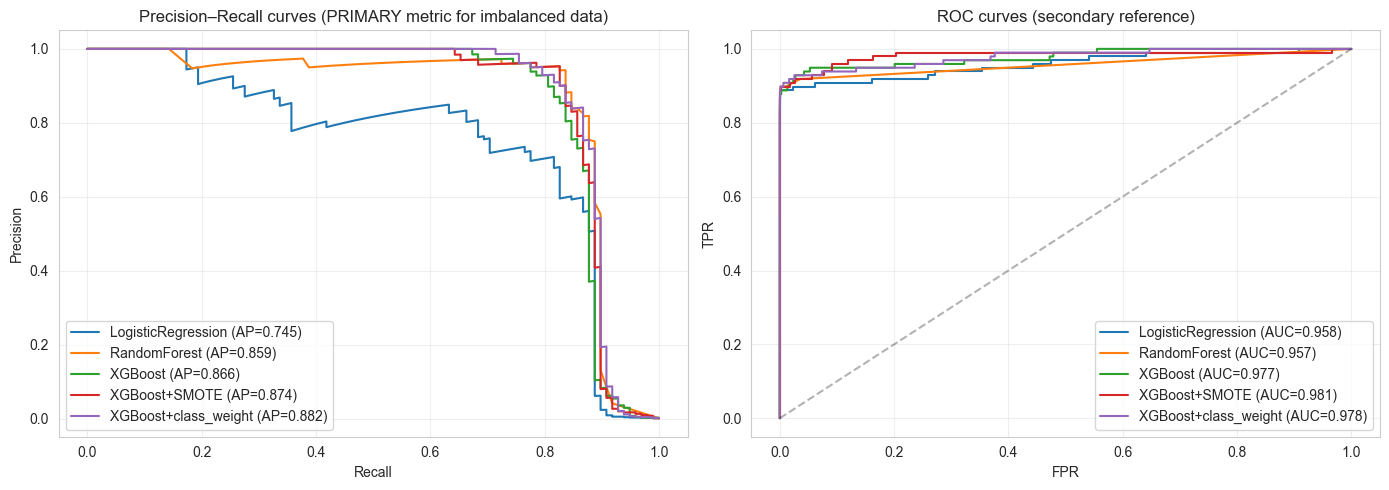

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall curves (PRIMARY metric for imbalanced data)")
axes[0].legend(loc='lower left'); axes[0].grid(True, alpha=0.3)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC curves (secondary reference)")
axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [9]:
best_name = comparison.index[0]
best_model = models[best_name]
print(f"Winner by PR-AUC: {best_name}")


Winner by PR-AUC: XGBoost+class_weight


## 6. Cost matrix and threshold

Cost matrix:

|                      | Predict Legit (0) | Predict Fraud (1) |
| -------------------- | ----------------- | ----------------- |
| Actual Legit (0)     | 0 (TN)            | C_FP              |
| Actual Fraud (1)     | C_FN              | 0 (TP, stopped)   |

C_FN (missed fraud). Baseline: mean fraud amount, about $122 from the EDA above. That's the money the bank loses when fraud gets through. Real banks also pay chargeback processing ($15 to $30) plus churn, so production usually uses something like `C_FN ≈ mean × 1.3 to 1.5`. Here we start at the transaction amount and keep it as a config value.

C_FP (false alarm). Analyst review time (about $1 to $2 for a 2-minute review) plus customer friction when a real transaction gets declined or stepped up. Friction is the fuzzy part. Baseline $5, with a sensitivity sweep below.

TP saves C_FN minus a small review cost (about $1). TN is zero.

Expected cost at threshold t:

$$E[\text{Cost}](t) = \text{FN}(t) \cdot C_{FN} + \text{FP}(t) \cdot C_{FP}$$

t* is the argmin on the test set.


In [10]:
# ---- Cost configuration (EDIT THESE WITH THE FRAUD OPS TEAM) ----
C_FN = float(mean_fraud_amount)   # ≈ $122; dollars lost per missed fraud
C_FP = 5.0                        # $5; analyst review + customer friction
# -----------------------------------------------------------------

proba_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.001, 0.999, 400)
fn_counts = np.zeros(len(thresholds), dtype=int)
fp_counts = np.zeros(len(thresholds), dtype=int)
for i, t in enumerate(thresholds):
    pred = (proba_best >= t).astype(int)
    fn_counts[i] = ((pred == 0) & (y_test == 1)).sum()
    fp_counts[i] = ((pred == 1) & (y_test == 0)).sum()

costs = fn_counts * C_FN + fp_counts * C_FP
t_star = thresholds[np.argmin(costs)]
cost_star = costs.min()

pred_05 = (proba_best >= 0.5).astype(int)
cost_05 = ((pred_05 == 0) & (y_test == 1)).sum() * C_FN + ((pred_05 == 1) & (y_test == 0)).sum() * C_FP
cost_allow_all = (y_test == 1).sum() * C_FN                   # threshold=1.0, flag nothing
cost_block_all = (y_test == 0).sum() * C_FP                   # threshold=0.0, flag everything

print(f"Optimal threshold  t*        : {t_star:.4f}")
print(f"Expected cost      @ t*      : ${cost_star:,.2f}")
print(f"Expected cost      @ t=0.5   : ${cost_05:,.2f}   ({(cost_05-cost_star)/max(cost_star,1)*100:+.1f}% vs t*)")
print(f"Expected cost      allow-all : ${cost_allow_all:,.2f}")
print(f"Expected cost      block-all : ${cost_block_all:,.2f}")
print(f"Net saving vs allow-all      : ${cost_allow_all - cost_star:,.2f}")

# Metrics at t*
pred_star = (proba_best >= t_star).astype(int)
print(f"\nAt t*={t_star:.4f}:  precision={precision_score(y_test, pred_star):.3f}  "
      f"recall={recall_score(y_test, pred_star):.3f}  "
      f"f1={f1_score(y_test, pred_star):.3f}")


Optimal threshold  t*        : 0.0210
Expected cost      @ t*      : $1,504.32
Expected cost      @ t=0.5   : $2,010.38   (+33.6% vs t*)
Expected cost      allow-all : $11,976.71
Expected cost      block-all : $284,320.00
Net saving vs allow-all      : $10,472.38

At t*=0.0210:  precision=0.731  recall=0.888  f1=0.802


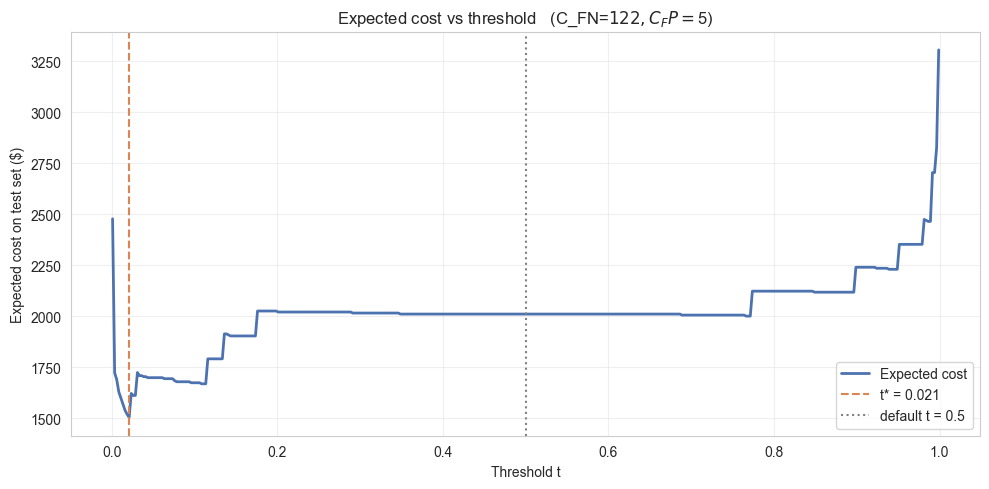

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color='#4c72b0', lw=2, label="Expected cost")
ax.axvline(t_star, color='#dd8452', linestyle='--', label=f"t* = {t_star:.3f}")
ax.axvline(0.5, color='grey', linestyle=':', label="default t = 0.5")
ax.set_xlabel("Threshold t"); ax.set_ylabel("Expected cost on test set ($)")
ax.set_title(f"Expected cost vs threshold   (C_FN=${C_FN:.0f}, C_FP=${C_FP:.0f})")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 6.1 Sensitivity: how much does t* move if the costs are off?

Finance will push back on the numbers. The main question: if C_FP is wrong, how far does t* shift? Sweep below.


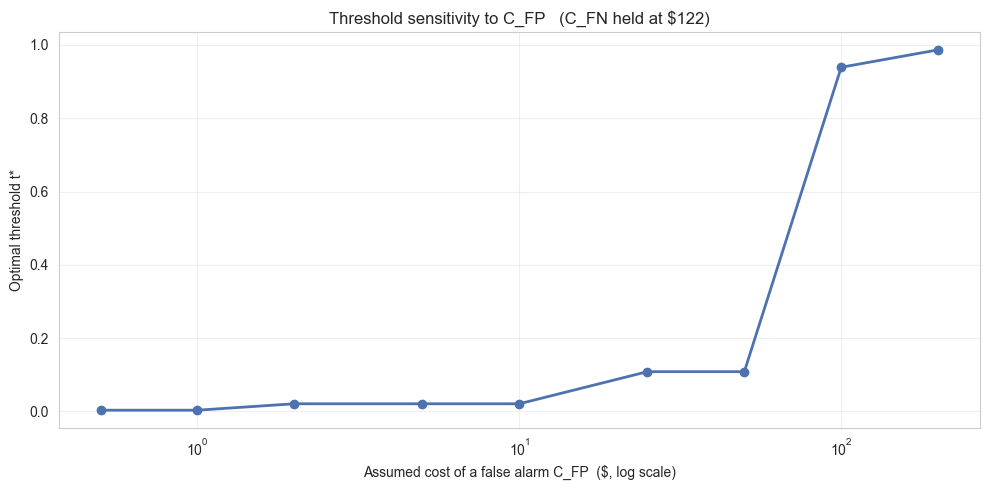

,C_FP ($),t*,Min cost ($)
0,0.5,0.004,"1,272.11"
1,1.0,0.004,"1,322.11"
2,2.0,0.021,"1,408.32"
3,5.0,0.021,"1,504.32"
4,10.0,0.021,"1,664.32"
5,25.0,0.109,"1,988.75"
6,50.0,0.109,"2,388.75"
7,100.0,0.939,"2,799.80"
8,200.0,0.986,"3,244.23"


In [12]:
cfp_range = np.array([0.5, 1, 2, 5, 10, 25, 50, 100, 200])
t_stars, min_costs = [], []
for cfp in cfp_range:
    c = fn_counts * C_FN + fp_counts * cfp
    t_stars.append(thresholds[np.argmin(c)])
    min_costs.append(c.min())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cfp_range, t_stars, 'o-', lw=2, color='#4c72b0')
ax.set_xscale('log')
ax.set_xlabel("Assumed cost of a false alarm C_FP  ($, log scale)")
ax.set_ylabel("Optimal threshold t*")
ax.set_title(f"Threshold sensitivity to C_FP   (C_FN held at ${C_FN:.0f})")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({
    'C_FP ($)':        cfp_range,
    't*':              t_stars,
    'Min cost ($)':    min_costs,
}).style.format({'C_FP ($)': '{:.1f}', 't*': '{:.3f}', 'Min cost ($)': '{:,.2f}'})


## 7. Two-tier threshold

Banks rarely run a single cutoff. Two thresholds work better:

- `t_block`: auto-decline. Needs high precision (target ≥ 90%) so we don't cancel legit customers in bulk.
- `t_review`: analyst queue or step-up auth. Lower threshold, favouring recall (target ≥ 90%) so fraud doesn't slip through.

Production routing:

| Score                            | Action                                       |
| -------------------------------- | -------------------------------------------- |
| `score < t_review`               | allow (pass through, no friction)            |
| `t_review ≤ score < t_block`     | review (step-up auth or analyst queue)       |
| `score ≥ t_block`                | block (auto-decline)                         |


In [13]:
prec, rec, thr_pr = precision_recall_curve(y_test, proba_best)
# precision_recall_curve → thresholds increasing, prec/rec length n+1 (last point degenerate)

# t_block: smallest threshold with precision ≥ 0.90
block_cands = np.where(prec[:-1] >= 0.90)[0]
t_block = float(thr_pr[block_cands[0]]) if len(block_cands) else 1.0

# t_review: largest threshold with recall ≥ 0.90
review_cands = np.where(rec[:-1] >= 0.90)[0]
t_review = float(thr_pr[review_cands[-1]]) if len(review_cands) else 0.0

# Keep them sensibly ordered
t_review = min(t_review, t_star, t_block)
t_block  = max(t_block,  t_star)

print(f"t_review (recall ≥ 0.90 target):   {t_review:.4f}")
print(f"t*       (min expected cost):      {t_star:.4f}")
print(f"t_block  (precision ≥ 0.90):       {t_block:.4f}")

def policy(p):
    if p >= t_block: return 'block'
    if p >= t_review: return 'review'
    return 'allow'

actions = np.array([policy(p) for p in proba_best])
print("\nTest-set volumes and fraud rate by action:")
for a in ['block', 'review', 'allow']:
    m = actions == a
    fraud_in_bucket = y_test.values[m].sum() if m.any() else 0
    print(f"  {a:7s}: {m.sum():>6,d} txns  | fraud in bucket: {fraud_in_bucket:>4d}  "
          f"| fraud rate {y_test.values[m].mean()*100 if m.any() else 0:>6.2f}%")

caught = ((actions == 'block') | (actions == 'review')) & (y_test.values == 1)
print(f"\nFraud caught (block+review): {caught.sum()} of {y_test.sum()} "
      f"({caught.sum()/y_test.sum()*100:.1f}% recall)")


t_review (recall ≥ 0.90 target):   0.0005
t*       (min expected cost):      0.0210
t_block  (precision ≥ 0.90):       0.7737

Test-set volumes and fraud rate by action:
  block  :     91 txns  | fraud in bucket:   82  | fraud rate  90.11%
  review :    364 txns  | fraud in bucket:    7  | fraud rate   1.92%
  allow  : 56,507 txns  | fraud in bucket:    9  | fraud rate   0.02%

Fraud caught (block+review): 89 of 98 (90.8% recall)


## 8. SHAP on the best model

Two views:

1. Global: which V-features are driving most of the fraud calls.
2. Local: waterfalls for a caught fraud, a missed fraud, and a false alarm. Useful when analysts are checking individual cases.


In [14]:
# Unwrap if the winner is the SMOTE pipeline
shap_model = best_model.named_steps['xgb'] if hasattr(best_model, 'named_steps') else best_model

# Subsample for speed — SHAP on 57k test rows is slow and unnecessary for the summary
rng = np.random.RandomState(SEED)
bg_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[bg_idx]
y_shap = y_test.iloc[bg_idx].values

explainer = shap.TreeExplainer(shap_model)
shap_expl = explainer(X_shap)


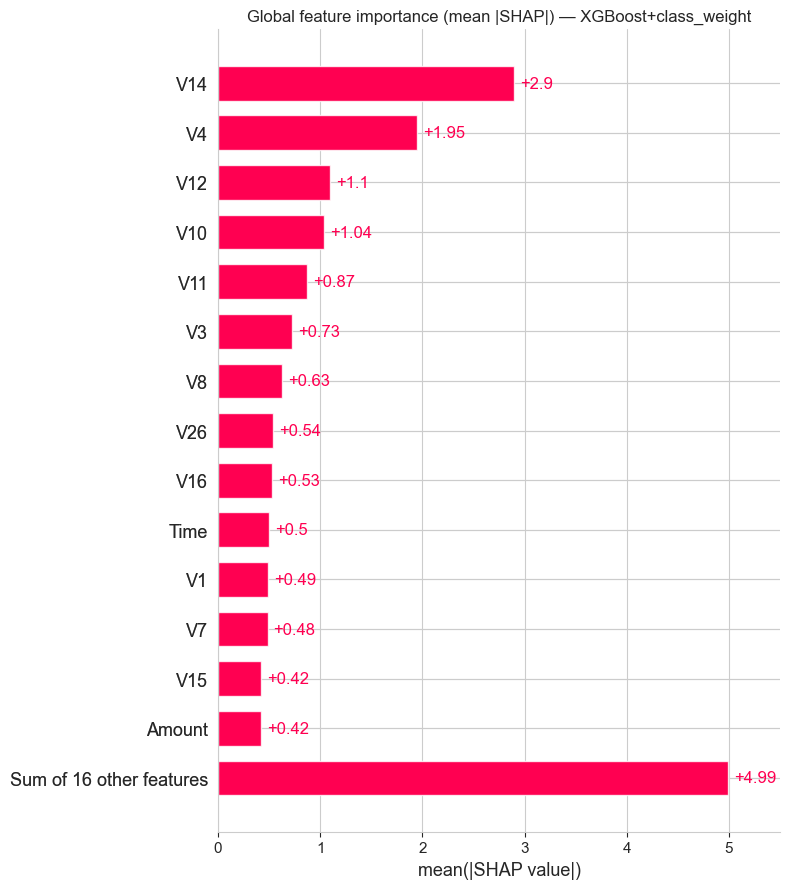

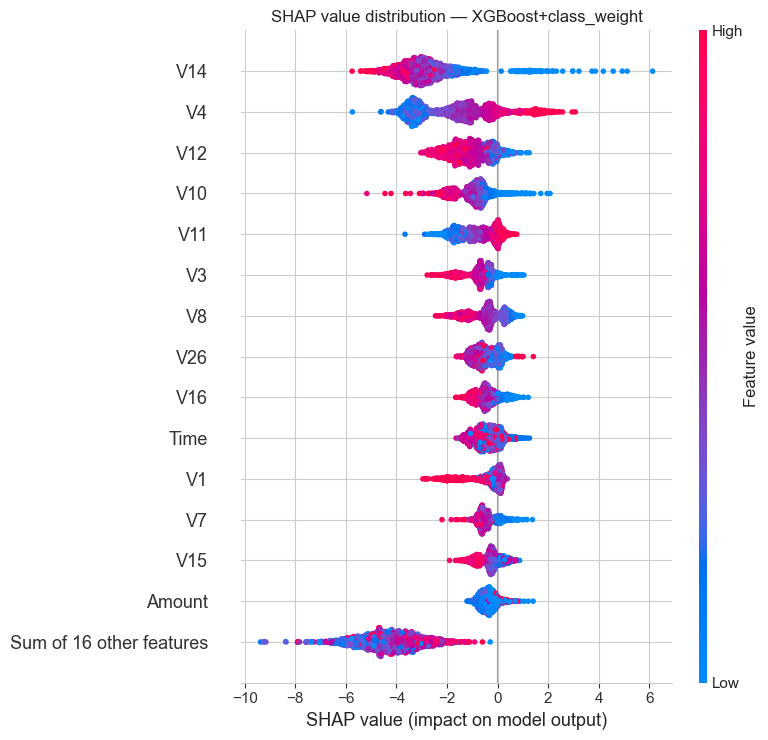

In [15]:
# Global — bar summary
shap.plots.bar(shap_expl, show=False, max_display=15)
plt.title(f"Global feature importance (mean |SHAP|) — {best_name}")
plt.tight_layout(); plt.show()

# Global — beeswarm
shap.plots.beeswarm(shap_expl, show=False, max_display=15)
plt.title(f"SHAP value distribution — {best_name}")
plt.tight_layout(); plt.show()



TRUE POSITIVE (caught fraud)   score = 1.0000


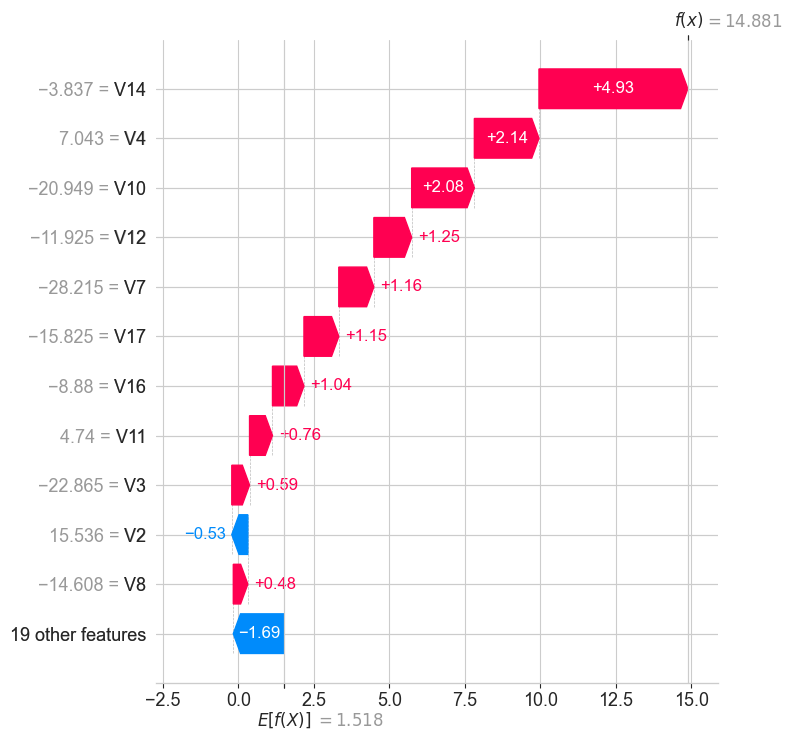

[no FALSE NEGATIVE (missed fraud) in SHAP sample at t*=0.021]

FALSE POSITIVE (false alarm)   score = 0.0237


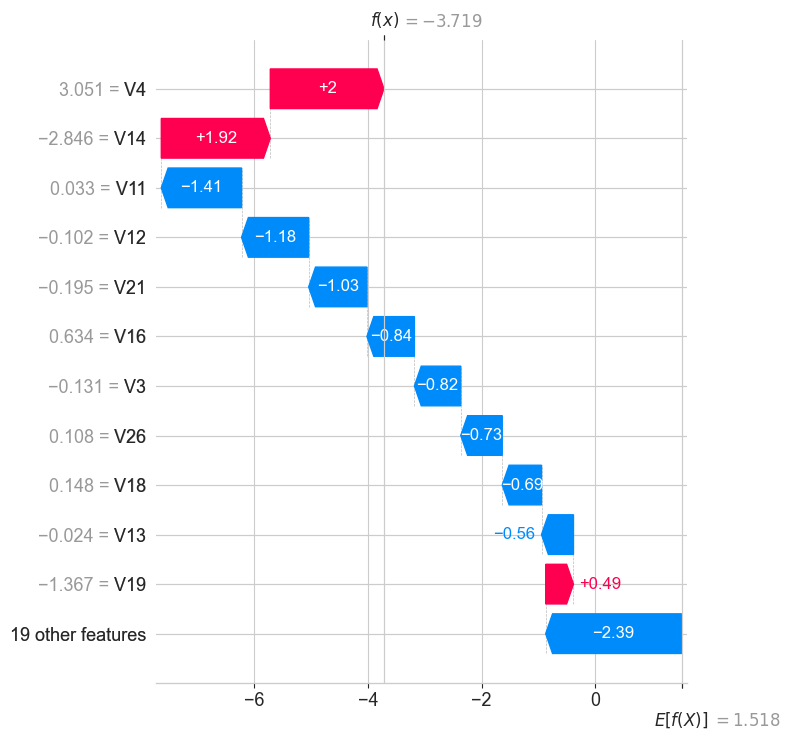

In [16]:
# Local waterfalls: one each of TP, FN, FP at t*
preds_shap = shap_model.predict_proba(X_shap)[:, 1]

case_indices = {
    'TRUE POSITIVE (caught fraud)':  np.where((preds_shap >= t_star) & (y_shap == 1))[0],
    'FALSE NEGATIVE (missed fraud)': np.where((preds_shap <  t_star) & (y_shap == 1))[0],
    'FALSE POSITIVE (false alarm)':  np.where((preds_shap >= t_star) & (y_shap == 0))[0],
}

for label, idx_list in case_indices.items():
    if len(idx_list) == 0:
        print(f"[no {label} in SHAP sample at t*={t_star:.3f}]")
        continue
    i = idx_list[0]
    print(f"\n{label}   score = {preds_shap[i]:.4f}")
    shap.plots.waterfall(shap_expl[i], show=False, max_display=12)
    plt.tight_layout(); plt.show()


### 8.1 Reading the SHAP output

- Top features on this run: V14, V4, V12, V10, V11. These are PCA components, so we can't read them directly. The bank's own team, with the pre-PCA features, can map them back to behaviour signals.
- Time lands mid-pack. Amount sits near the bottom. Don't expect dollar value or time of day alone to drive the score. The model is going off patterns in the V-features.
- For analysts: trust the score over the obvious surface features. A $2 transaction scored 0.95 is more suspicious than a $2,000 transaction scored 0.3.


## 9. Artifact packaging


In [17]:
artifact = {
    'model':            best_model,
    'model_name':       best_name,
    'scaler':           scaler,
    'feature_columns':  list(X_train.columns),
    'thresholds':       {'t_review': float(t_review),
                         't_star':   float(t_star),
                         't_block':  float(t_block)},
    'cost_matrix':      {'C_FN': float(C_FN), 'C_FP': float(C_FP)},
    'metrics':          {k: float(v) for k, v in comparison.loc[best_name].items()},
    'trained_on':       {'n_train': int(len(X_train)),
                         'n_test':  int(len(X_test)),
                         'pos_rate': float(y_train.mean())},
    'notes':            "Threshold is part of the model. Do not hard-code thresholds downstream.",
}
with open(ARTIFACT_PATH, 'wb') as f:
    pickle.dump(artifact, f)

print(f"Saved → {ARTIFACT_PATH}")
print(json.dumps({k: v for k, v in artifact.items()
                  if k not in ('model', 'scaler', 'feature_columns')},
                 indent=2, default=str))


Saved → fraud_model_artifact.pkl
{
  "model_name": "XGBoost+class_weight",
  "thresholds": {
    "t_review": 0.0005368568818084896,
    "t_star": 0.021010025062656642,
    "t_block": 0.7737462520599365
  },
  "cost_matrix": {
    "C_FN": 122.21132113821139,
    "C_FP": 5.0
  },
  "metrics": {
    "PR-AUC": 0.8817163602073214,
    "ROC-AUC": 0.9778171046133703,
    "Precision@0.5": 0.8817204301075269,
    "Recall@0.5": 0.8367346938775511,
    "F1@0.5": 0.8586387434554974
  },
  "trained_on": {
    "n_train": 227845,
    "n_test": 56962,
    "pos_rate": 0.001729245759178389
  },
  "notes": "Threshold is part of the model. Do not hard-code thresholds downstream."
}


## 10. Handoff: what ops does next

1. Use the score. At inference, scale Time and Amount with the saved scaler, run `predict_proba`, route using the three-tier policy.
2. Weekly monitoring: score drift (KS test against training scores), precision at block tier (from chargeback and confirmed-fraud feedback), recall at review tier (audit of confirmed frauds), review queue vs analyst capacity, false-decline complaints.
3. Retrain triggers: PR-AUC drops more than 5 points on the rolling holdout; block-tier precision below 90% for two weeks; a new attack pattern scores below `t_review`; quarterly regardless.
4. Cost matrix review: check `C_FN` and `C_FP` with fraud finance every quarter. The plot in §6.1 shows how `t*` would shift.
5. Shadow Isolation Forest: run it in parallel as a drift and novel-attack monitor. Alert if its flag rate jumps on transactions the model scores low.
6. Fairness audit: the Kaggle features are anonymized, but the bank's internal data is not. Before go-live, check the score against protected attributes on internal data.
